# Hermès Bag Authenticator — Training Pipeline
### Setup → Preprocess → Train → Evaluate → Inference

In [9]:
!pip install rembg onnxruntime -q

## 1. Create project files
Each `%%writefile` cell saves a `.py` file to disk. **Update `RAW_DATA_DIR` below** to match your dataset path.

In [1]:
%%writefile config.py
"""
Central configuration for the Hermès Bag Authenticator.
"""

import os
import torch
import random
import numpy as np

# =============================================================
# ⚠️  UPDATE THIS PATH to match your Kaggle dataset
# =============================================================
RAW_DATA_DIR = "/Users/ignaciouriz/Documents/IE/YEAR II/YEAR III/SEM II/AI/Hermes Authenticator/Dataset" # ← CHANGE THIS

PROCESSED_DATA_DIR = "/Users/ignaciouriz/Documents/IE/YEAR II/YEAR III/SEM II/AI/Hermes Authenticator/Processed_Dataset"
OUTPUT_DIR = "/Users/ignaciouriz/Documents/IE/YEAR II/YEAR III/SEM II/AI/Hermes Authenticator/Outputs"

TRAIN_DIR = os.path.join(PROCESSED_DATA_DIR, "train")
VAL_DIR = os.path.join(PROCESSED_DATA_DIR, "val")
TEST_DIR = os.path.join(PROCESSED_DATA_DIR, "test")

BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_model.pth")

# Data split
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# Image
IMG_SIZE = 224
BACKGROUND_COLOR = (255, 255, 255)

# Training
BATCH_SIZE = 32
NUM_EPOCHS = 30
LEARNING_RATE = 1e-3
FINE_TUNE_LR = 1e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 7
UNFREEZE_AFTER = 5

# Classes
CLASS_NAMES = ["Fake", "Real"]
NUM_CLASSES = 2

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reproducibility
SEED = 42

def seed_everything(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Writing config.py


In [9]:
%%writefile preprocess.py
"""
Preprocessing: background removal with rembg (BiRefNet) + train/val/test split.
Only processes NEW images not already in the processed cache.
"""
import os
import shutil
from pathlib import Path
from PIL import Image
from rembg import remove, new_session
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import config

# Persistent cache of processed images (survives re-runs)
CACHE_DIR = os.path.join(config.PROCESSED_DATA_DIR, "_cache")


def remove_background(input_path, output_path, session) -> bool:
    try:
        img = Image.open(input_path).convert("RGBA")
        result = remove(img, session=session)
        white_bg = Image.new("RGBA", result.size, config.BACKGROUND_COLOR + (255,))
        white_bg.paste(result, mask=result.split()[3])
        final = white_bg.convert("RGB")
        final = final.resize((config.IMG_SIZE, config.IMG_SIZE), Image.LANCZOS)
        final.save(output_path, "JPEG", quality=95)
        return True
    except Exception as e:
        print(f"  [SKIP] {input_path}: {e}")
        return False


def process_class(class_name, raw_dir, session):
    input_dir = os.path.join(raw_dir, class_name)
    cache_class_dir = os.path.join(CACHE_DIR, class_name)
    os.makedirs(cache_class_dir, exist_ok=True)

    valid_ext = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
    image_files = [f for f in os.listdir(input_dir) if Path(f).suffix.lower() in valid_ext]

    if not image_files:
        print(f"  [WARNING] No images in {input_dir}")
        return

    # Check which images are already processed
    already_done = set(os.listdir(cache_class_dir))
    new_files = [f for f in image_files if (Path(f).stem + ".jpg") not in already_done]
    skipped = len(image_files) - len(new_files)

    print(f"\n'{class_name}': {len(image_files)} total | {skipped} cached | {len(new_files)} new to process")

    if not new_files:
        print(f"  All images already processed, skipping!")
        return

    for fname in tqdm(new_files, desc=f"  {class_name}"):
        in_path = os.path.join(input_dir, fname)
        out_fname = Path(fname).stem + ".jpg"
        out_path = os.path.join(cache_class_dir, out_fname)
        remove_background(in_path, out_path, session)

    total = len(os.listdir(cache_class_dir))
    print(f"  Done! Cache now has {total} images for '{class_name}'")


def split_and_organise():
    print("\n--- Splitting into train / val / test ---")

    # Clear old splits but keep cache
    for split in ["train", "val", "test"]:
        split_dir = os.path.join(config.PROCESSED_DATA_DIR, split)
        if os.path.exists(split_dir):
            shutil.rmtree(split_dir)

    for class_name in config.CLASS_NAMES:
        cache_class_dir = os.path.join(CACHE_DIR, class_name)
        if not os.path.exists(cache_class_dir):
            continue
        images = sorted(os.listdir(cache_class_dir))
        print(f"  '{class_name}': {len(images)} images")

        train_imgs, val_test_imgs = train_test_split(
            images, test_size=(config.VAL_RATIO + config.TEST_RATIO), random_state=config.SEED)
        relative_test = config.TEST_RATIO / (config.VAL_RATIO + config.TEST_RATIO)
        val_imgs, test_imgs = train_test_split(
            val_test_imgs, test_size=relative_test, random_state=config.SEED)

        print(f"    Train: {len(train_imgs)} | Val: {len(val_imgs)} | Test: {len(test_imgs)}")

        for split_name, file_list in [("train", train_imgs), ("val", val_imgs), ("test", test_imgs)]:
            dest = os.path.join(config.PROCESSED_DATA_DIR, split_name, class_name)
            os.makedirs(dest, exist_ok=True)
            for fname in file_list:
                shutil.copy2(os.path.join(cache_class_dir, fname), os.path.join(dest, fname))


def main():
    config.seed_everything()
    print("=" * 60)
    print("  Hermes Authenticator - Preprocessing")
    print("=" * 60)

    for cn in config.CLASS_NAMES:
        p = os.path.join(config.RAW_DATA_DIR, cn)
        if not os.path.isdir(p):
            raise FileNotFoundError(f"Expected '{p}'. Check RAW_DATA_DIR in config.py")

    session = new_session("birefnet-general")
    for cn in config.CLASS_NAMES:
        process_class(cn, config.RAW_DATA_DIR, session)

    split_and_organise()

    print("\n Done! Data saved to:", config.PROCESSED_DATA_DIR)
    print(" Cache kept at:", CACHE_DIR)


if __name__ == "__main__":
    main()

Overwriting preprocess.py


In [3]:
%%writefile dataset.py
"""
PyTorch Dataset with augmentation transforms.
"""

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import config

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


def get_train_transforms():
    return transforms.Compose([
        transforms.Resize((config.IMG_SIZE + 32, config.IMG_SIZE + 32)),
        transforms.RandomResizedCrop(config.IMG_SIZE, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomGrayscale(p=0.2),  # 20% of images converted to grayscale
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        transforms.RandomPerspective(distortion_scale=0.1, p=0.3),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def get_eval_transforms():
    return transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])


def get_dataloaders():
    train_dataset = datasets.ImageFolder(root=config.TRAIN_DIR, transform=get_train_transforms())
    val_dataset = datasets.ImageFolder(root=config.VAL_DIR, transform=get_eval_transforms())
    test_dataset = datasets.ImageFolder(root=config.TEST_DIR, transform=get_eval_transforms())

    print(f"Class mapping: {train_dataset.class_to_idx}")
    print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    return {
        "train": train_loader, "val": val_loader, "test": test_loader,
        "train_dataset": train_dataset, "val_dataset": val_dataset, "test_dataset": test_dataset,
    }

Writing dataset.py


In [4]:
%%writefile model.py
"""
EfficientNet-B0 with custom classifier head for binary classification.
"""

import torch
import torch.nn as nn
from torchvision import models
import config


def build_model(pretrained=True):
    if pretrained:
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        model = models.efficientnet_b0(weights=weights)
    else:
        model = models.efficientnet_b0(weights=None)

    for param in model.features.parameters():
        param.requires_grad = False

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(512, config.NUM_CLASSES),
    )
    return model


def unfreeze_backbone(model, num_blocks_to_unfreeze=3):
    total_blocks = len(model.features)
    unfreeze_from = total_blocks - num_blocks_to_unfreeze
    for i, block in enumerate(model.features):
        if i >= unfreeze_from:
            for param in block.parameters():
                param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  Unfroze last {num_blocks_to_unfreeze} blocks: {trainable:,}/{total:,} params trainable")


def get_optimizer(model, fine_tuning=False):
    if not fine_tuning:
        return torch.optim.Adam(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
    else:
        backbone_params, head_params = [], []
        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue
            if "classifier" in name:
                head_params.append(param)
            else:
                backbone_params.append(param)
        return torch.optim.Adam([
            {"params": backbone_params, "lr": config.FINE_TUNE_LR},
            {"params": head_params, "lr": config.LEARNING_RATE},
        ], weight_decay=config.WEIGHT_DECAY)

Writing model.py


In [5]:
%%writefile train.py
"""
Training with two-phase transfer learning + early stopping.
"""

import os, time
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm

import config
from dataset import get_dataloaders
from model import build_model, unfreeze_backbone, get_optimizer


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="  Training", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="  Validating", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    return running_loss / total, correct / total


def plot_curves(log_df, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(log_df["epoch"], log_df["train_loss"], label="Train", marker="o", ms=3)
    axes[0].plot(log_df["epoch"], log_df["val_loss"], label="Val", marker="o", ms=3)
    if config.UNFREEZE_AFTER < log_df["epoch"].max():
        axes[0].axvline(x=config.UNFREEZE_AFTER, color="gray", ls="--", alpha=0.7, label="Unfreeze")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(log_df["epoch"], log_df["train_acc"], label="Train", marker="o", ms=3)
    axes[1].plot(log_df["epoch"], log_df["val_acc"], label="Val", marker="o", ms=3)
    if config.UNFREEZE_AFTER < log_df["epoch"].max():
        axes[1].axvline(x=config.UNFREEZE_AFTER, color="gray", ls="--", alpha=0.7, label="Unfreeze")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.savefig(save_path, dpi=150, bbox_inches="tight"); plt.close()
    print(f"  Curves saved -> {save_path}")


def main():
    config.seed_everything()
    os.makedirs(config.OUTPUT_DIR, exist_ok=True)

    print("=" * 60)
    print("  Hermes Authenticator - Training")
    print("=" * 60)
    print(f"  Device: {config.DEVICE}")

    data = get_dataloaders()
    train_loader, val_loader = data["train"], data["val"]

    # Class weights for imbalance
    train_dataset = data["train_dataset"]
    class_counts = [0] * config.NUM_CLASSES
    for _, label in train_dataset:
        class_counts[label] += 1
    total_samples = sum(class_counts)
    class_weights = torch.tensor([total_samples / c for c in class_counts], dtype=torch.float).to(config.DEVICE)
    print(f"Class counts: {dict(zip(config.CLASS_NAMES, class_counts))}")

    model = build_model(pretrained=True).to(config.DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = get_optimizer(model, fine_tuning=False)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    best_val_loss = float("inf")
    patience_counter = 0
    log_rows = []
    start = time.time()

    for epoch in range(1, config.NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{config.NUM_EPOCHS}")

        if epoch == config.UNFREEZE_AFTER + 1:
            print("\n*** Phase 2: Unfreezing backbone ***")
            unfreeze_backbone(model, num_blocks_to_unfreeze=3)
            optimizer = get_optimizer(model, fine_tuning=True)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, config.DEVICE)
        val_loss, val_acc = validate(model, val_loader, criterion, config.DEVICE)
        scheduler.step(val_loss)

        print(f"  Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

        log_rows.append({"epoch": epoch, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc})

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), config.BEST_MODEL_PATH)
            print(f"  Best model saved (val_loss={val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  No improvement ({patience_counter}/{config.PATIENCE})")
            if patience_counter >= config.PATIENCE:
                print(f"  Early stopping at epoch {epoch}")
                break

    print(f"\nDone in {(time.time()-start)/60:.1f} min. Best val_loss: {best_val_loss:.4f}")

    log_df = pd.DataFrame(log_rows)
    log_df.to_csv(os.path.join(config.OUTPUT_DIR, "training_log.csv"), index=False)
    plot_curves(log_df, os.path.join(config.OUTPUT_DIR, "training_curves.png"))

if __name__ == "__main__":
    main()

Writing train.py


In [6]:
%%writefile evaluate.py
"""
Test set evaluation: classification report, confusion matrix, error analysis.
"""

import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from sklearn.metrics import classification_report, confusion_matrix

import config
from dataset import get_dataloaders, IMAGENET_MEAN, IMAGENET_STD
from model import build_model


def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = (tensor.cpu() * std + mean).clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_labels, all_probs, all_images = [], [], [], []
    for images, labels in loader:
        outputs = model(images.to(device))
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
        all_images.extend(images.cpu())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs), all_images


def plot_confusion_matrix(y_true, y_pred, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=config.CLASS_NAMES, yticklabels=config.CLASS_NAMES, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title("Confusion Matrix - Test Set")
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.close()
    print(f"  Confusion matrix -> {save_path}")


def plot_errors(images, labels, preds, probs, save_path, max_show=12):
    wrong = np.where(labels != preds)[0]
    if len(wrong) == 0:
        print("  No errors!"); return
    confs = [(i, probs[i][preds[i]]) for i in wrong]
    confs.sort(key=lambda x: -x[1])
    n = min(max_show, len(confs))
    cols = 4; rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    axes = np.array(axes).flatten()
    for i, (idx, conf) in enumerate(confs[:n]):
        axes[i].imshow(denormalize(images[idx]))
        axes[i].set_title(f"True: {config.CLASS_NAMES[labels[idx]]}\nPred: {config.CLASS_NAMES[preds[idx]]} ({conf:.0%})", color="red", fontsize=10)
        axes[i].axis("off")
    for j in range(n, len(axes)): axes[j].axis("off")
    fig.suptitle(f"Misclassified ({len(wrong)} total errors)")
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.close()
    print(f"  Error analysis -> {save_path}")


def main():
    config.seed_everything()
    os.makedirs(config.OUTPUT_DIR, exist_ok=True)
    print("=" * 60)
    print("  Hermes Authenticator - Evaluation")
    print("=" * 60)

    model = build_model(pretrained=False)
    model.load_state_dict(torch.load(config.BEST_MODEL_PATH, map_location=config.DEVICE))
    model = model.to(config.DEVICE)

    data = get_dataloaders()
    preds, labels, probs, images = get_predictions(model, data["test"], config.DEVICE)

    print("\n--- Classification Report ---\n")
    report = classification_report(labels, preds, target_names=config.CLASS_NAMES, digits=4)
    print(report)

    with open(os.path.join(config.OUTPUT_DIR, "classification_report.txt"), "w") as f:
        f.write(report)

    plot_confusion_matrix(labels, preds, os.path.join(config.OUTPUT_DIR, "confusion_matrix.png"))
    plot_errors(images, labels, preds, probs, os.path.join(config.OUTPUT_DIR, "error_analysis.png"))

    acc = (preds == labels).mean()
    print(f"\n  Test Accuracy: {acc:.4f} ({acc:.1%})")
    print(f"  Misclassified: {(preds != labels).sum()} / {len(labels)}")

if __name__ == "__main__":
    main()

Writing evaluate.py


In [7]:
%%writefile inference.py
"""
Single image inference.
"""

import argparse
import torch
from PIL import Image
from rembg import remove

import config
from dataset import get_eval_transforms
from model import build_model


def preprocess_image(image_path):
    img = Image.open(image_path).convert("RGBA")
    result = remove(img)
    white_bg = Image.new("RGBA", result.size, config.BACKGROUND_COLOR + (255,))
    white_bg.paste(result, mask=result.split()[3])
    final = white_bg.convert("RGB")
    transform = get_eval_transforms()
    return transform(final).unsqueeze(0)


@torch.no_grad()
def predict(model, image_tensor, device):
    model.eval()
    outputs = model(image_tensor.to(device))
    probs = torch.softmax(outputs, dim=1)
    confidence, idx = probs.max(1)
    return config.CLASS_NAMES[idx.item()], confidence.item()


def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--image", type=str, required=True)
    parser.add_argument("--model", type=str, default=config.BEST_MODEL_PATH)
    args = parser.parse_args()

    model = build_model(pretrained=False)
    model.load_state_dict(torch.load(args.model, map_location=config.DEVICE))
    model = model.to(config.DEVICE)

    image_tensor = preprocess_image(args.image)
    pred, conf = predict(model, image_tensor, config.DEVICE)

    print(f"\n  Prediction: {pred.upper()}")
    print(f"  Confidence: {conf:.1%}")
    if pred == "fake":
        print("  Warning: This bag shows signs of being counterfeit.")
    else:
        print("  This bag appears authentic (screening only).")

if __name__ == "__main__":
    main()

Writing inference.py


In [8]:
%%writefile gradcam.py
"""
Grad-CAM visualization: shows which regions of the bag the model focuses on.
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

import config
from model import build_model
from inference import preprocess_image
from dataset import IMAGENET_MEAN, IMAGENET_STD


def generate_gradcam(model, image_tensor, target_class=None):
    model.eval()
    
    # Hook into the last conv layer of EfficientNet
    activations = []
    gradients = []
    
    def forward_hook(module, input, output):
        activations.append(output)
    
    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])
    
    # Register hooks on the last feature block
    target_layer = model.features[-1]
    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)
    
    # Forward pass
    image_tensor = image_tensor.to(config.DEVICE)
    image_tensor.requires_grad_(True)
    output = model(image_tensor)
    probs = torch.softmax(output, dim=1)
    
    if target_class is None:
        target_class = output.argmax(dim=1).item()
    
    # Backward pass for the target class
    model.zero_grad()
    output[0, target_class].backward()
    
    # Compute Grad-CAM
    acts = activations[0].detach()
    grads = gradients[0].detach()
    weights = grads.mean(dim=[2, 3], keepdim=True)  # global avg pool of gradients
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = F.relu(cam)  # only positive contributions
    cam = F.interpolate(cam, size=(config.IMG_SIZE, config.IMG_SIZE), mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)  # normalize 0-1
    
    # Clean up hooks
    fh.remove()
    bh.remove()
    
    return cam, target_class, probs.detach().cpu().numpy()[0]


def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = (tensor.cpu().squeeze() * std + mean).clamp(0, 1)
    return img.permute(1, 2, 0).numpy()


def visualize_gradcam(image_path, save_path="outputs/gradcam_result.png"):
    model = build_model(pretrained=False)
    model.load_state_dict(torch.load(config.BEST_MODEL_PATH, map_location=config.DEVICE))
    model = model.to(config.DEVICE)
    
    image_tensor = preprocess_image(image_path)
    cam, pred_class, probs = generate_gradcam(model, image_tensor)
    original = denormalize(image_tensor)
    
    pred_label = config.CLASS_NAMES[pred_class]
    confidence = probs[pred_class]
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    axes[0].imshow(original)
    axes[0].set_title("Original Image")
    axes[0].axis("off")
    
    # Heatmap only
    axes[1].imshow(cam, cmap="jet")
    axes[1].set_title("Grad-CAM Heatmap")
    axes[1].axis("off")
    
    # Overlay
    axes[2].imshow(original)
    axes[2].imshow(cam, cmap="jet", alpha=0.5)
    axes[2].set_title(f"Prediction: {pred_label.upper()} ({confidence:.1%})")
    axes[2].axis("off")
    
    plt.suptitle("Grad-CAM: Where is the model looking?", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {save_path}")


if __name__ == "__main__":
    import argparse
    parser = argparse.ArgumentParser()
    parser.add_argument("--image", type=str, required=True)
    args = parser.parse_args()
    visualize_gradcam(args.image)

Writing gradcam.py


## 2. Run the pipeline

### Step 1: Preprocess (background removal + split)
This takes a few minutes depending on dataset size.

In [10]:
!python preprocess.py

  Hermes Authenticator - Preprocessing

'Fake': 197 total | 74 cached | 123 new to process
  Fake:  15%|████▉                           | 19/123 [17:13<1:15:10, 43.37s/it]/Users/ignaciouriz/Documents/IE/YEAR II/YEAR III/SEM II/AI/Hermes Authenticator/.venv/lib/python3.10/site-packages/rembg/sessions/birefnet_general.py:18: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-mat))
  Fake: 100%|███████████████████████████████| 123/123 [2:49:55<00:00, 82.89s/it]
  Done! Cache now has 197 images for 'Fake'

'Real': 411 total | 409 cached | 2 new to process
  Real: 100%|█████████████████████████████████████| 2/2 [01:09<00:00, 34.87s/it]
  Done! Cache now has 411 images for 'Real'

--- Splitting into train / val / test ---
  'Fake': 197 images
    Train: 137 | Val: 30 | Test: 30
  'Real': 411 images
    Train: 287 | Val: 62 | Test: 62

 Done! Data saved to: /Users/ignaciouriz/Documents/IE/YEAR II/YEAR III/SEM II/AI/Hermes Authenticator/Processed_Dataset
 Cache kept at: /Use

### Step 2: Train

In [13]:

!python train.py

  Hermes Authenticator - Training
  Device: mps
Class mapping: {'Fake': 0, 'Real': 1}
Train: 424 | Val: 92 | Test: 92
Class counts: {'Fake': 137, 'Real': 287}

Epoch 1/30
  Training:   0%|                                        | 0/14 [00:00<?, ?it/s]/Users/ignaciouriz/Documents/IE/YEAR II/YEAR III/SEM II/AI/Hermes Authenticator/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
  Train Loss: 0.6085 | Acc: 0.6981                                              
  Val   Loss: 0.4227 | Acc: 0.8587
  Best model saved (val_loss=0.4227)

Epoch 2/30
  Train Loss: 0.3545 | Acc: 0.8703                                              
  Val   Loss: 0.3757 | Acc: 0.7935
  Best model saved (val_loss=0.3757)

Epoch 3/30
  Train Loss: 0.2972 | Acc: 0.8750                                              
  Val   Loss: 0.3093 | Acc: 0.8478
  Best m

### Step 3: Evaluate on test set

In [14]:
!python evaluate.py

  Hermes Authenticator - Evaluation
Class mapping: {'Fake': 0, 'Real': 1}
Train: 424 | Val: 92 | Test: 92
/Users/ignaciouriz/Documents/IE/YEAR II/YEAR III/SEM II/AI/Hermes Authenticator/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)

--- Classification Report ---

              precision    recall  f1-score   support

        Fake     0.9062    0.9667    0.9355        30
        Real     0.9833    0.9516    0.9672        62

    accuracy                         0.9565        92
   macro avg     0.9448    0.9591    0.9513        92
weighted avg     0.9582    0.9565    0.9569        92

  Confusion matrix -> /Users/ignaciouriz/Documents/IE/YEAR II/YEAR III/SEM II/AI/Hermes Authenticator/Outputs/confusion_matrix.png
  Error analysis -> /Users/ignaciouriz/Documents/IE/YEAR II/YEAR III/SEM II/AI/Hermes Authenticator/Outputs/e

### View outputs


--- training_curves.png ---


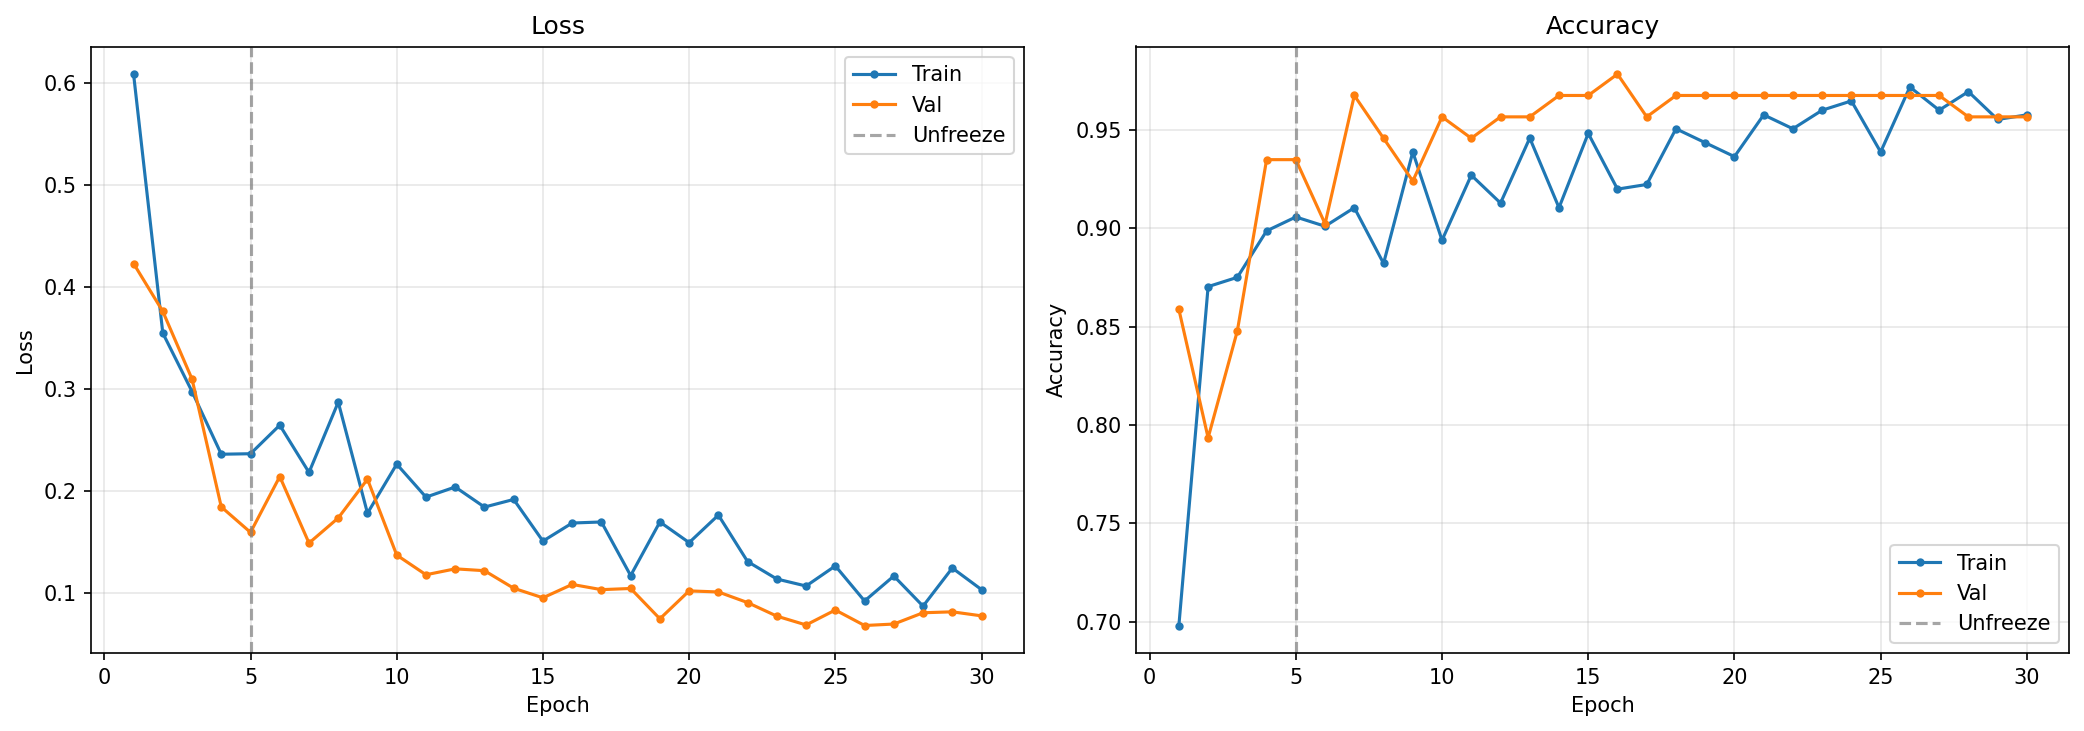


--- confusion_matrix.png ---


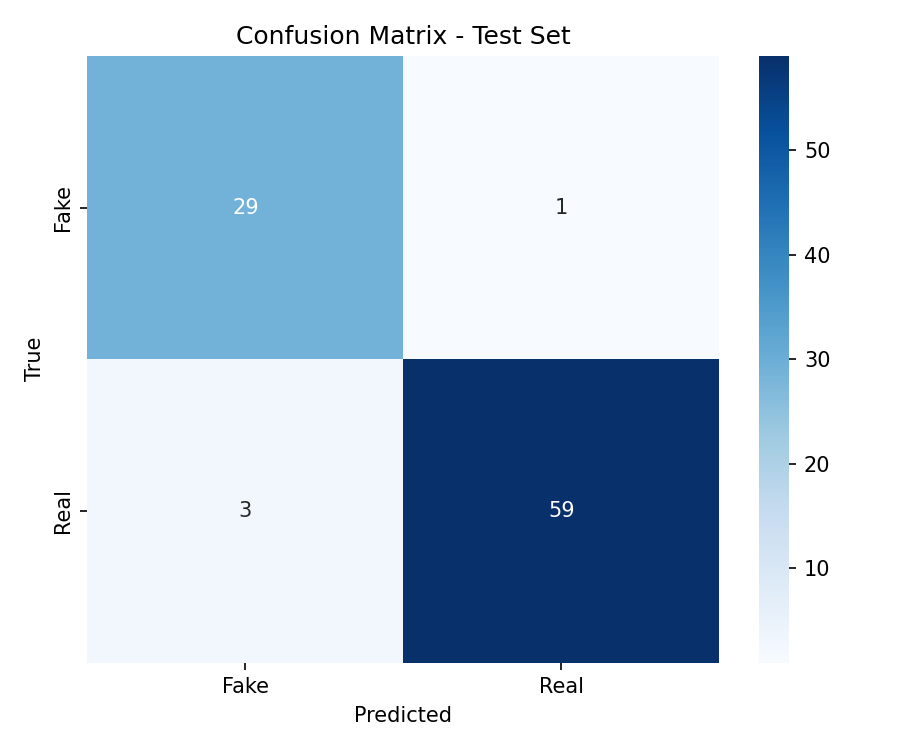


--- error_analysis.png ---


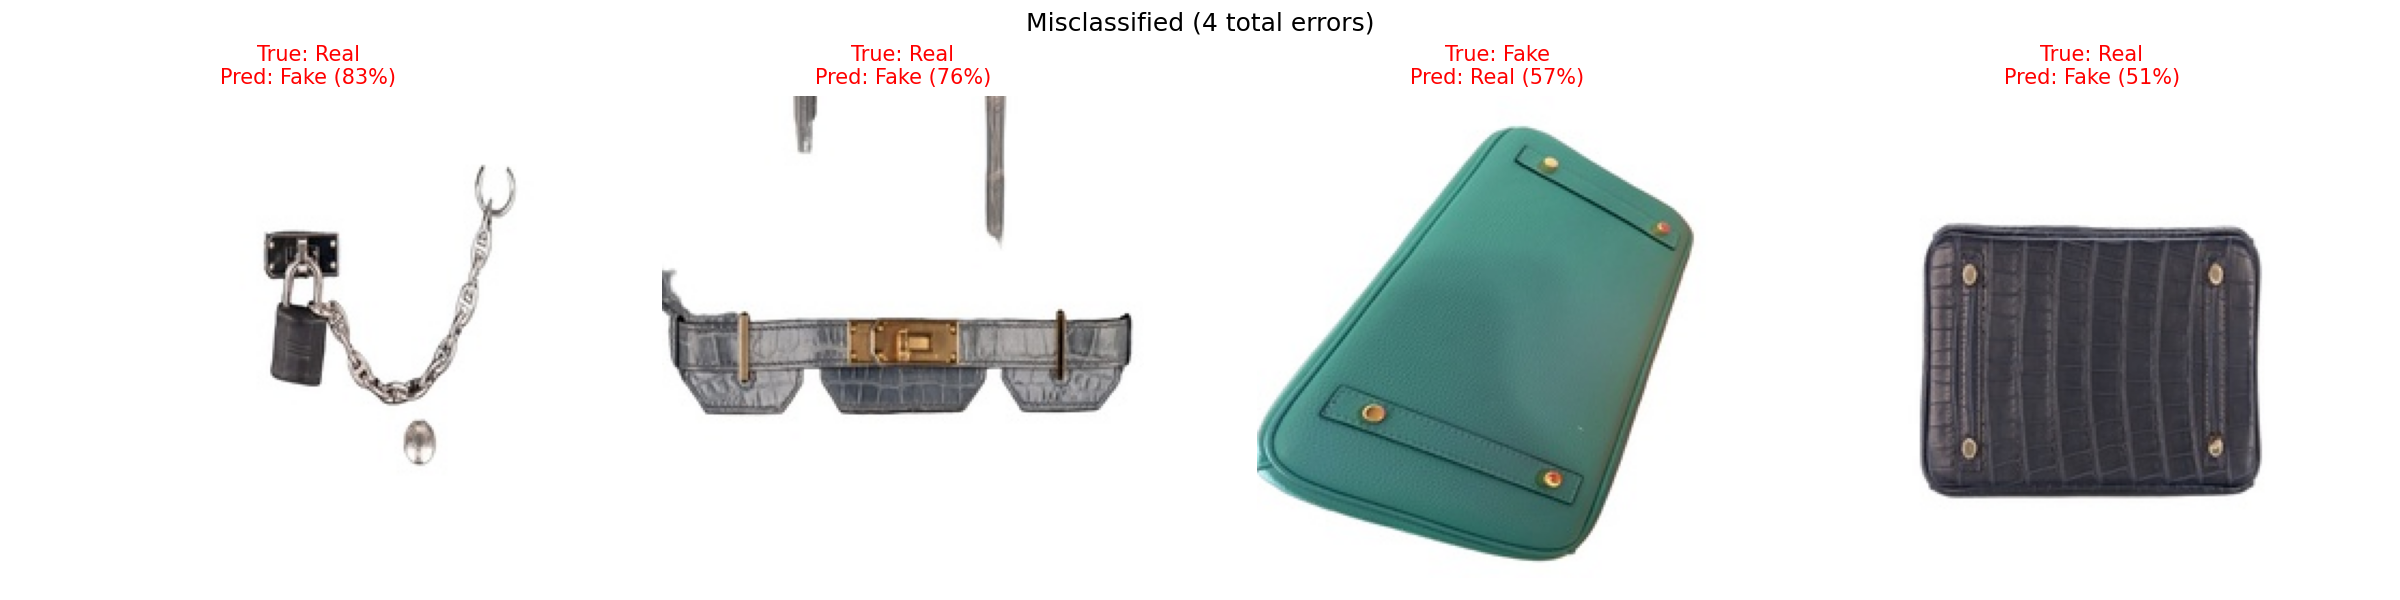

In [15]:
from IPython.display import display, Image as IPImage
import os

outputs_dir = "outputs"
for fname in ["training_curves.png", "confusion_matrix.png", "error_analysis.png"]:
    path = os.path.join(outputs_dir, fname)
    if os.path.exists(path):
        print(f"\n--- {fname} ---")
        display(IPImage(filename=path))
    

In [11]:
!python cross_validate.py

  Hermès Authenticator — 3-Fold Cross-Validation
  Device: mps

  Total images: 608
  Class distribution: {'Fake': np.int64(197), 'Real': np.int64(411)}


  FOLD 1/3
  Train: 405 | Val: 203
    Training:   0%|                                      | 0/13 [00:00<?, ?it/s]/Users/ignaciouriz/Documents/IE/YEAR II/YEAR III/SEM II/AI/Hermes Authenticator/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
    Epoch  1/30  Train: 0.6105 / 0.7284  Val: 0.4508 / 0.8818                   
    Epoch  2/30  Train: 0.3679 / 0.8691  Val: 0.4672 / 0.7094                   
    Epoch  3/30  Train: 0.2766 / 0.8765  Val: 0.3732 / 0.8030                   
    Epoch  4/30  Train: 0.2873 / 0.8716  Val: 0.2410 / 0.8818                   
    Epoch  5/30  Train: 0.2262 / 0.9012  Val: 0.1807 / 0.9212                   
    Unfreezing backbone at epo

### Step 4: Test on a single image

In [16]:
# Change this path to any image you want to test
!python inference.py --image IMG_7786.PNG


  Prediction: REAL
  Confidence: 64.7%
  This bag appears authentic (screening only).


In [17]:
!python gradcam.py --image IMG_7786.PNG

Figure(1500x500)
Saved → outputs/gradcam_result.png


In [4]:
!pip install -r requirements.txt

  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (2.4 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached h11-0.16.0-py3-none-any.whl (37 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 10.2 MB/s  0:00:00
Using cached annotated_types-0.7.0-py3-none-any.whl (13 kB)
Using cached anyio-4.13.0-py3-none-any.whl (114 kB)
Using cached pyyaml-6.0.3-cp310-cp310-macosx_11_0_arm64.whl (174 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [fastapi]7/18 [fastapi]e]tipart]
